# 📊 Stage 5: Post-Training Evaluation & Comparative Analysis
**Project:** Reduction Ladder for Code & Multi-Arm Mitigation  
**Organization:** Orange Innovation Labs  
**Authors:** Omar Abdelhamid, Nour Walid  
**Supervisor:** Dr. Ghada Soliman  

---

### 🎯 Objectives:
1. **Evaluate Models on Reduction Ladder (L0–L5)**:
   - **M1**: Zero-Shot Baseline (`Qwen2.5-Coder-1.5B-Instruct`)
   - **M2**: Vanilla CoT Distillation (`Qwen2.5-Coder-1.5B-Instruct + QLoRA Adapter`)
   - *(Dynamically evaluates M3 or RL Arm models if their checkpoints are detected)*
2. **Quantify Metrics**:
   - **Ladder AUC**: Area Under the Degradation Curve
   - **Collapse Point $\ell^*$**: First perturbation level where Pass@1 drops below 50%
   - **Consistency Delta $\Delta C$**: Performance retention from L0 to L1–L5
3. **Generate Publication Figures**: Plot comparative degradation curves.

In [1]:
import os
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is on sys.path
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.path.abspath("."))

from src.core.config import get_settings
from src.shared.engine import EvaluationEngine
from src.stage5_comparison.analysis_service import AnalysisService

settings = get_settings()
RESULTS_DIR = settings.storage.results_dir
DATA_CACHE = settings.storage.ladder_cache_dir
BASE_MODEL = settings.models.student_model

os.makedirs(RESULTS_DIR, exist_ok=True)
print("[OK] Evaluation Environment Initialized:")
print(f"   Base Model   : {BASE_MODEL}")
print(f"   Results Dir  : {RESULTS_DIR}")
print(f"   Ladder Cache : {DATA_CACHE}")

c:\Users\Lenovo\anaconda3\envs\unsloth_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
c:\Users\Lenovo\anaconda3\envs\unsloth_env\lib\site-packages\transformers\utils\hub.py:105: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


[OK] Evaluation Environment Initialized:
   Base Model   : Qwen/Qwen2.5-Coder-1.5B-Instruct
   Results Dir  : results
   Ladder Cache : data/ladder


---
## 1. Dynamic Model Registry

Registers M1 (Baseline) and M2 (Vanilla SFT). Automatically detects any trained checkpoints (e.g., M3 or Inv-GRPO) if available.

In [2]:
MODELS_TO_EVAL = {
    "M1 — Baseline": {
        "model_name": BASE_MODEL,
        "adapter_path": None,
        "output_tag": "baseline",
    },
    "M2 — Vanilla SFT": {
        "model_name": BASE_MODEL,
        "adapter_path": settings.qlora.vanilla_output_dir,
        "output_tag": "distilled_vanilla",
    },
}

# Optional: check if contrastive or RL adapter exists
if os.path.exists(settings.qlora.contrastive_output_dir):
    MODELS_TO_EVAL["M3 — Contrastive SFT"] = {
        "model_name": BASE_MODEL,
        "adapter_path": settings.qlora.contrastive_output_dir,
        "output_tag": "distilled_contrastive",
    }

if os.path.exists(settings.inv_grpo.output_dir):
    MODELS_TO_EVAL["M6 — Inv-GRPO"] = {
        "model_name": BASE_MODEL,
        "adapter_path": settings.inv_grpo.output_dir,
        "output_tag": "inv_grpo",
    }

print("[LIST] Models Configured for Evaluation:")
for label, cfg in MODELS_TO_EVAL.items():
    status = "(Ready / Adapter found)" if (cfg['adapter_path'] is None or os.path.exists(cfg['adapter_path'])) else "(Adapter pending)"
    print(f"   - {label:26s} | Adapter: {str(cfg['adapter_path']):35s} {status}")

suite_reports = {}


[LIST] Models Configured for Evaluation:
   - M1 — Baseline              | Adapter: None                                (Ready / Adapter found)
   - M2 — Vanilla SFT           | Adapter: checkpoints/qlora_vanilla_adapter   (Ready / Adapter found)
   - M6 — Inv-GRPO              | Adapter: checkpoints/inv_grpo_final          (Ready / Adapter found)


---
## 2. Execute Full Ladder Evaluation (L0–L5)

Loads the model into GPU memory, runs evaluations across all ladder benchmarks, and caches individual level reports.

In [ ]:
suite_reports = {}

for model_label, cfg in MODELS_TO_EVAL.items():
    tag = cfg['output_tag']
    report_path = os.path.join(RESULTS_DIR, tag, f"suite_report_{tag}.json")

    # If cached results exist, load them to avoid redundant GPU execution
    if os.path.exists(report_path):
        print(f"\n[CACHE HIT] Loading cached evaluation for '{model_label}'...")
        with open(report_path, "r", encoding="utf-8") as f:
            suite_reports[model_label] = json.load(f)
        continue

    # Skip if adapter required but missing
    if cfg['adapter_path'] is not None and not os.path.exists(cfg['adapter_path']):
        print(f"\n[WARN] Skipping '{model_label}': adapter not found at '{cfg['adapter_path']}'.")
        continue

    print(f"\n{'='*65}")
    print(f"[EVAL] Evaluating: {model_label}")
    print(f"   Model  : {cfg['model_name']}")
    print(f"   Adapter: {cfg['adapter_path'] or 'None (Zero-Shot)'}")
    print(f"{'='*65}")

    engine = EvaluationEngine(
        model_name=cfg['model_name'],
        adapter_path=cfg['adapter_path'],
        data_cache_dir=DATA_CACHE,
        results_dir=RESULTS_DIR,
    )

    report = engine.run_full_ladder(
        output_tag=tag,
        evaluate_pass5=False,
        timeout_seconds=settings.evaluation.timeout_seconds,
    )
    suite_reports[model_label] = report.to_dict() if hasattr(report, "to_dict") else report
    print(f"[OK] Completed evaluation for: {model_label}")

print(f"\n[OK] Evaluation Complete. Evaluated models: {list(suite_reports.keys())}")


[CACHE HIT] Loading cached evaluation for 'M1 — Baseline'...

[EVAL] Evaluating: M2 — Vanilla SFT
   Model  : Qwen/Qwen2.5-Coder-1.5B-Instruct
   Adapter: checkpoints/qlora_vanilla_adapter
[MODEL] Loading tokenizer for 'Qwen/Qwen2.5-Coder-1.5B-Instruct' (cache: D:/hf_cache)...
[MODEL] Loading 4-bit NF4 quantized model: 'Qwen/Qwen2.5-Coder-1.5B-Instruct'...


Skipping import of cpp extensions due to incompatible torch version 2.6.0+cu124 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


[MODEL] Loading LoRA adapter weights from 'checkpoints/qlora_vanilla_adapter'...
[MODEL] Model successfully loaded and ready for inference.

[EVAL] Evaluating Level: L0 (164 tasks)...
  [GEN]  Generating Pass@1 completions in batches of 8...


L0 batches:   0%|          | 0/21 [00:00<?, ?batch/s]c:\Users\Lenovo\anaconda3\envs\unsloth_env\lib\site-packages\transformers\generation\configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
c:\Users\Lenovo\anaconda3\envs\unsloth_env\lib\site-packages\transformers\generation\configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
c:\Users\Lenovo\anaconda3\envs\unsloth_env\lib\site-packages\transformers\generation\configuration_utils.py:653: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  

  [EXEC] Running sandbox execution in parallel...


L0 exec: 100%|██████████| 164/164 [00:00<00:00, 178.66it/s]


[OK] L0 Result: Pass@1 = 64.63%
     Error Breakdown: {'pass': 106, 'syntax_error': 58}

[EVAL] Evaluating Level: L1 (100 tasks)...
  [GEN]  Generating Pass@1 completions in batches of 8...


L1 batches:  92%|█████████▏| 12/13 [20:22<01:37, 97.52s/batch]

---
## 3. Performance Summary Table

Pass@1 per level, Ladder AUC, and Collapse Point $\ell^*$.

In [ ]:
if suite_reports:
    summary_df = AnalysisService.compute_summary_table(suite_reports)
    print("\n[SUMMARY] Reduction Ladder Performance Summary:")
    display(summary_df)
else:
    print("[WARN] No evaluation reports found. Run evaluation cells above first.")


[SUMMARY] Reduction Ladder Performance Summary:


,Model,L0 (HumanEval),L1 (Subtle),L2 (ToolUse),L3 (Creative),L4 (Difficult),L5 (Combine),Ladder AUC,Collapse Point,Consistency Delta
0,M1 — Baseline,93.3%,87.0%,83.0%,77.0%,77.0%,76.0%,82.2%,None (Maintained > 50%),4.0%
1,M2 — Vanilla SFT,0.0%,0.0%,4.0%,4.0%,4.0%,3.0%,2.5%,L0,4.0%


---
## 4. Pass@1 Degradation Curves

Visualizing the trajectory of performance across the Reduction Ladder (L0 through L5).

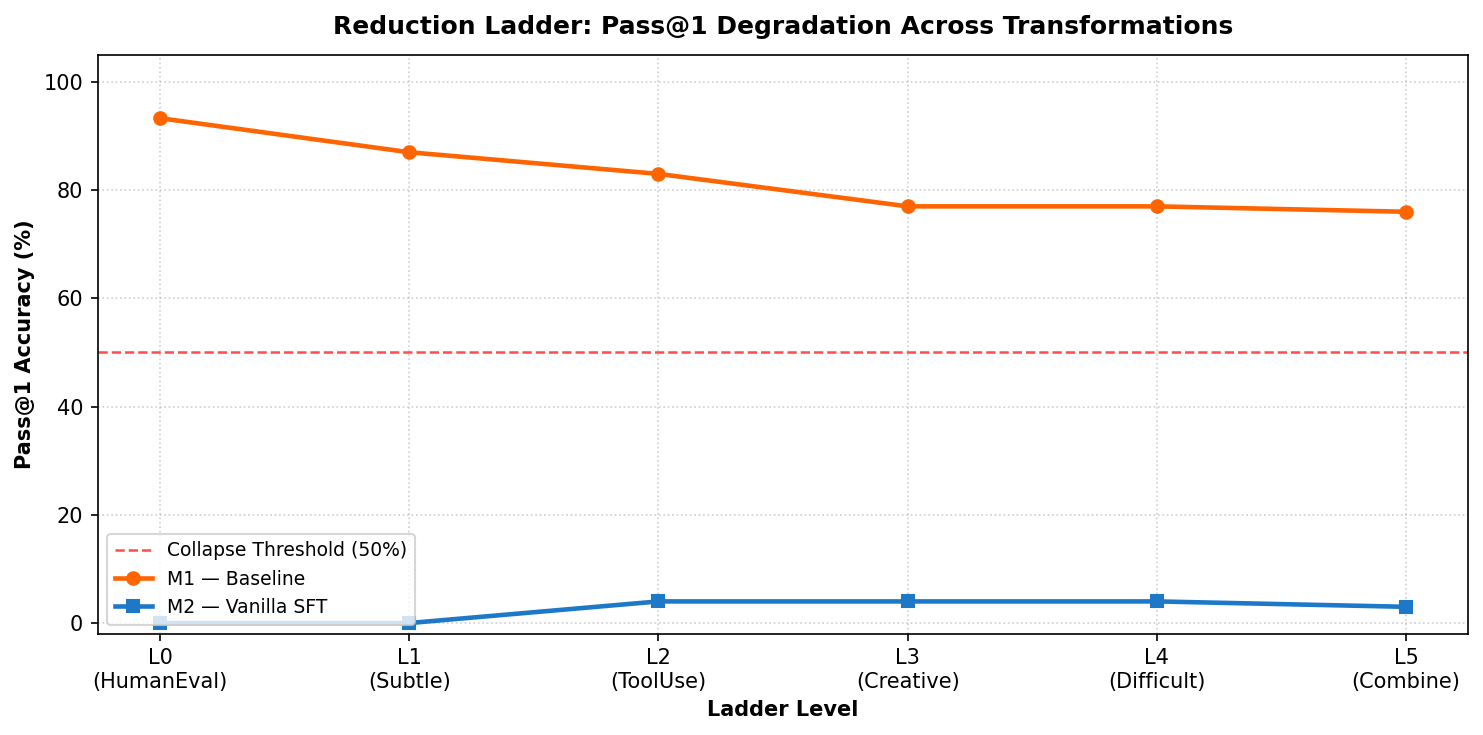

[OK] Comparison figure saved to: results\multi_model_comparison.png


In [ ]:
LEVELS = ["L0", "L1", "L2", "L3", "L4", "L5"]
LEVEL_LABELS = ["L0\n(HumanEval)", "L1\n(Subtle)", "L2\n(ToolUse)",
                "L3\n(Creative)", "L4\n(Difficult)", "L5\n(Combine)"]

colors = ["#FF6400", "#1E78C8", "#28A745", "#9B51E0"]
markers = ["o", "s", "^", "D"]

fig_path = os.path.join(RESULTS_DIR, "multi_model_comparison.png")

plt.figure(figsize=(10, 5), dpi=150)
plt.axhline(50.0, color="red", linestyle="--", alpha=0.7, linewidth=1.2, label="Collapse Threshold (50%)")

for idx, (model_label, rep) in enumerate(suite_reports.items()):
    level_reps = rep.get("level_reports", {})
    scores = [level_reps.get(lvl, {}).get("pass_at_1", 0.0) * 100 for lvl in LEVELS]
    plt.plot(LEVELS, scores,
             marker=markers[idx % len(markers)],
             color=colors[idx % len(colors)],
             linewidth=2.2, label=model_label)

plt.title("Reduction Ladder: Pass@1 Degradation Across Transformations", fontsize=12, fontweight="bold", pad=10)
plt.xlabel("Ladder Level", fontsize=10, fontweight="bold")
plt.ylabel("Pass@1 Accuracy (%)", fontsize=10, fontweight="bold")
plt.xticks(range(6), LEVEL_LABELS)
plt.ylim(-2, 105)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(frameon=True, loc="lower left", fontsize=9)
plt.tight_layout()
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"[OK] Comparison figure saved to: {fig_path}")

---
## 5. Delta Analysis: Does Vanilla SFT Solve Mimicry?

We examine the absolute difference $\Delta = \text{Pass@1}(M2) - \text{Pass@1}(M1)$ at each level.
- If $\Delta$ is positive on L0 but collapses on L2–L5, this confirms our core scientific hypothesis: **Vanilla CoT distillation improves raw coding capacity on standard benchmarks, but fails to prevent shortcut mimicry under surface perturbations!**

In [ ]:
baseline_label = "M1 — Baseline"
if baseline_label in suite_reports:
    base_reps = suite_reports[baseline_label].get("level_reports", {})
    delta_rows = []
    for lvl in LEVELS:
        b_score = base_reps.get(lvl, {}).get("pass_at_1", 0.0) * 100
        row = {"Level": lvl, f"{baseline_label} (%)": f"{b_score:.1f}"}
        for model_label, rep in suite_reports.items():
            if model_label == baseline_label: continue
            m_score = rep.get("level_reports", {}).get(lvl, {}).get("pass_at_1", 0.0) * 100
            delta = m_score - b_score
            sign = "+" if delta >= 0 else ""
            row[f"{model_label} Δ"] = f"{sign}{delta:.1f}%"
        delta_rows.append(row)
    print("\n[SUMMARY] Delta Improvement relative to M1 Baseline:")
    display(pd.DataFrame(delta_rows))
else:
    print("Baseline report not found for delta comparison.")


[SUMMARY] Delta Improvement relative to M1 Baseline:


,Level,M1 — Baseline (%),M2 — Vanilla SFT Δ
0,L0,93.3,-93.3%
1,L1,87.0,-87.0%
2,L2,83.0,-79.0%
3,L3,77.0,-73.0%
4,L4,77.0,-73.0%
5,L5,76.0,-73.0%
